In [18]:
import numpy as np
import pandas as pd

In [19]:
outfits = pd.read_csv("datasets/outfits.csv")
users = pd.read_csv("datasets/Users.csv")
recommendation = pd.read_csv("datasets/recommendation.csv")
skincare = pd.read_csv("datasets/skincare.csv")
haircare = pd.read_csv("datasets/haircare.csv")

In [20]:
print(outfits.head())

  dress_id category fit_type primary_color  fabric event_type
0       D1     Gown    Loose          Pink  Velvet      Party
1       D2    Kurti     Slim         Black    Silk    Wedding
2       D3     Gown     Slim           Red  Velvet    College
3       D4    Kurti  Regular          Pink    Silk    Wedding
4       D5    Kurti     Slim          Pink  Cotton  Reception


In [7]:
print(users.head())

  user_id  gender   age  height_cm  weight_kg  body_type skin_tone hair_type  \
0      U1  Female  23.0      166.0         75       Pear    Medium      Wavy   
1      U2  Female  27.0      149.0         61   Athletic      Dark  Straight   
2      U3  Female  23.0      170.0         61  Rectangle      Fair     Curly   
3      U4  Female  29.0      163.0         54  Rectangle      Fair      Wavy   
4      U5  Female  24.0      153.0         51  Rectangle      Fair      Wavy   

  hair_color  
0      Black  
1      Brown  
2      Brown  
3      Black  
4      Black  


In [21]:

print(recommendation.head())

  user_id event_type dress_id  body_match_score  style_score  final_ratings
0   U3936    Wedding     D176              0.63         0.95              3
1   U2095    Wedding     D160              0.72         0.91              3
2    U744    Wedding      D28              0.61         0.91              4
3   U3748  Reception      D80              0.99         0.64              5
4   U3941  Reception     D139              0.65         0.84              4


In [22]:
print(skincare.head())

   product_id       product_name  skin_type product_category price_range
0        2613     Cleanser L 483  Sensitive         Cleanser      Medium
1        6811  Moisturizer F 511        Dry      Moisturizer      Medium
2        3278        Serum O 708     Normal            Serum        High
3        6978     Cleanser Q 205       Oily         Cleanser         Low
4        1075    Sunscreen C 208     Normal        Sunscreen      Medium


In [23]:

print(haircare.head())

   product_id       product_name      hair_type routine_type
0        8005  Conditioner N 870   Scalp Issues         Wash
1        4755  Conditioner F 429   Low Porosity         Wash
2        5464    Hair Mask C 787   Low Porosity    Treatment
3        7208        Serum L 288  High Porosity    Treatment
4        1509        Serum H 331   Low Porosity    Treatment


### MISSING VALUES

In [24]:
print(outfits.isnull().sum())  

dress_id          0
category         10
fit_type          0
primary_color     0
fabric            0
event_type        5
dtype: int64


In [25]:
print(users.isnull().sum())  

user_id        0
gender         0
age           10
height_cm      5
weight_kg      0
body_type      5
skin_tone      0
hair_type      0
hair_color     0
dtype: int64


In [26]:
print(skincare.isnull().sum()) 

product_id          0
product_name        0
skin_type           0
product_category    0
price_range         0
dtype: int64


In [27]:
print(recommendation.isnull().sum())

user_id             0
event_type          0
dress_id            0
body_match_score    0
style_score         0
final_ratings       0
dtype: int64


In [28]:
print(recommendation.isnull())

       user_id  event_type  dress_id  body_match_score  style_score  \
0        False       False     False             False        False   
1        False       False     False             False        False   
2        False       False     False             False        False   
3        False       False     False             False        False   
4        False       False     False             False        False   
...        ...         ...       ...               ...          ...   
49995    False       False     False             False        False   
49996    False       False     False             False        False   
49997    False       False     False             False        False   
49998    False       False     False             False        False   
49999    False       False     False             False        False   

       final_ratings  
0              False  
1              False  
2              False  
3              False  
4              False  
...      

In [29]:
print(haircare.isnull().sum())   

product_id       0
product_name     0
hair_type       20
routine_type     0
dtype: int64


### IF missing values detected

In [30]:
# Convert to numeric, invalid parsing becomes NaN
users['age'] = pd.to_numeric(users['age'], errors='coerce')
users['height_cm'] = pd.to_numeric(users['height_cm'], errors='coerce')
users['weight_kg'] = pd.to_numeric(users['weight_kg'], errors='coerce')

# Fill missing values
users['body_type'] = users['body_type'].fillna("Unknown")
users['skin_tone'] = users['skin_tone'].fillna("Unknown")
users['hair_type'] = users['hair_type'].fillna("Unknown")
users['gender'] = users['gender'].fillna("Unknown")

# Numeric columns: fill missing with mean
users['age'] = users['age'].fillna(users['age'].mean()).astype(int)
users['height_cm'] = users['height_cm'].fillna(users['height_cm'].mean())
users['weight_kg'] = users['weight_kg'].fillna(users['weight_kg'].mean())

# Standardize text to lowercase
users['body_type'] = users['body_type'].str.lower()
users['skin_tone'] = users['skin_tone'].str.lower()
users['hair_type'] = users['hair_type'].str.lower()
users['gender'] = users['gender'].str.lower()

In [31]:
outfits['category'] = outfits['category'].fillna("Unknown").str.lower()
outfits['fit_type'] = outfits['fit_type'].fillna("Unknown").str.lower()
outfits['primary_color'] = outfits['primary_color'].fillna("Unknown").str.lower()
outfits['fabric'] = outfits['fabric'].fillna("Unknown").str.lower()
outfits['event_type'] = outfits['event_type'].fillna("Unknown").str.lower()

In [32]:

haircare['hair_type'] = haircare['hair_type'].fillna("Unknown").str.lower()
haircare['product_name'] = haircare['product_name'].fillna("Unknown").str.lower()


In [33]:

recommendation['body_match_score'] = pd.to_numeric(recommendation['body_match_score'], errors='coerce').fillna(0)
recommendation['style_score'] = pd.to_numeric(recommendation['style_score'], errors='coerce').fillna(0)
recommendation['final_ratings'] = pd.to_numeric(recommendation['final_ratings'], errors='coerce').fillna(0)

recommendation['user_id'] = recommendation['user_id'].fillna("Unknown").str.lower()
recommendation['dress_id'] = recommendation['dress_id'].fillna("Unknown").str.lower()
recommendation['event_type'] = recommendation['event_type'].fillna("Unknown").str.lower()

In [34]:
print(users.duplicated())
print("Number of duplicate rows:",users.duplicated().sum())


0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool
Number of duplicate rows: 0


In [35]:
print(outfits.duplicated())
print("Number of duplicate rows:", outfits.duplicated().sum())

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool
Number of duplicate rows: 0


In [36]:
print(skincare.duplicated())
print("Number of duplicate rows:", skincare.duplicated().sum())

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool
Number of duplicate rows: 0


In [37]:
print(haircare.duplicated())
print("Number of duplicate rows:", haircare.duplicated().sum())

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool
Number of duplicate rows: 0


In [38]:
print(recommendation.duplicated())
print("Number of duplicate rows:", recommendation.duplicated().sum())

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool
Number of duplicate rows: 0


In [40]:
## remove duplicates
outfits.drop_duplicates(inplace=True)
users.drop_duplicates(inplace=True)
skincare.drop_duplicates(inplace=True)
haircare.drop_duplicates(inplace=True)
recommendation.drop_duplicates(inplace=True)

In [41]:

print("Users missing values:\n", users.isnull().sum())
print("Outfits missing values:\n", outfits.isnull().sum())
print("Skincare missing values:\n", skincare.isnull().sum())

Users missing values:
 user_id       0
gender        0
age           0
height_cm     0
weight_kg     0
body_type     0
skin_tone     0
hair_type     0
hair_color    0
dtype: int64
Outfits missing values:
 dress_id         0
category         0
fit_type         0
primary_color    0
fabric           0
event_type       0
dtype: int64
Skincare missing values:
 product_id          0
product_name        0
skin_type           0
product_category    0
price_range         0
dtype: int64


In [42]:
print("Haircare missing values:\n", haircare.isnull().sum())
print("Recommendation missing values:\n", recommendation.isnull().sum())

Haircare missing values:
 product_id      0
product_name    0
hair_type       0
routine_type    0
dtype: int64
Recommendation missing values:
 user_id             0
event_type          0
dress_id            0
body_match_score    0
style_score         0
final_ratings       0
dtype: int64


In [43]:

# Skincare and Haircare
skincare['skin_type'] = skincare['skin_type'].str.lower()
haircare['hair_type'] = haircare['hair_type'].str.lower()

## Check data Types


In [44]:
print(outfits.dtypes)


dress_id         object
category         object
fit_type         object
primary_color    object
fabric           object
event_type       object
dtype: object


In [45]:

print(users.dtypes)


user_id        object
gender         object
age             int64
height_cm     float64
weight_kg       int64
body_type      object
skin_tone      object
hair_type      object
hair_color     object
dtype: object


In [46]:
print(skincare.dtypes)


product_id           int64
product_name        object
skin_type           object
product_category    object
price_range         object
dtype: object


In [47]:

print(haircare.dtypes)


product_id       int64
product_name    object
hair_type       object
routine_type    object
dtype: object


In [48]:
print(recommendation.dtypes)

user_id              object
event_type           object
dress_id             object
body_match_score    float64
style_score         float64
final_ratings         int64
dtype: object


### Data Consistency Check

In [49]:
print(users['age'].min(), users['age'].max())
print(users['height_cm'].min(), users['height_cm'].max())
print(users['weight_kg'].min(), users['weight_kg'].max())

18 35
145.0 175.0
45 75


In [50]:
## outfit datacheck
print(outfits['event_type'].unique())
print(outfits['category'].unique())

['party' 'wedding' 'college' 'reception' 'formal' 'festival' 'unknown']
['gown' 'kurti' 'suit' 'lehenga' 'unknown' 'saree']


In [51]:
## skincare data check
print(skincare['skin_type'].unique())
print(skincare['price_range'].unique())

['sensitive' 'dry' 'normal' 'oily']
['Medium' 'High' 'Low']


In [52]:
## haircare 
print(haircare['hair_type'].unique())
print(haircare['routine_type'].unique())

['scalp issues' 'low porosity' 'high porosity' 'unknown']
['Wash' 'Treatment']


In [53]:
## recommendation data consistency
print(recommendation[['body_match_score','style_score','final_ratings']].describe())

       body_match_score   style_score  final_ratings
count      50000.000000  50000.000000   50000.000000
mean           0.799866      0.800376       4.000240
std            0.115822      0.115172       0.818739
min            0.600000      0.600000       3.000000
25%            0.700000      0.700000       3.000000
50%            0.800000      0.800000       4.000000
75%            0.900000      0.900000       5.000000
max            1.000000      1.000000       5.000000


In [54]:
print(outfits.head())
print(users.head())
print(skincare['skin_type'].value_counts())
print(haircare['hair_type'].value_counts())
print(outfits['category'].value_counts())

  dress_id category fit_type primary_color  fabric event_type
0       D1     gown    loose          pink  velvet      party
1       D2    kurti     slim         black    silk    wedding
2       D3     gown     slim           red  velvet    college
3       D4    kurti  regular          pink    silk    wedding
4       D5    kurti     slim          pink  cotton  reception
  user_id  gender  age  height_cm  weight_kg  body_type skin_tone hair_type  \
0      U1  female   23      166.0         75       pear    medium      wavy   
1      U2  female   27      149.0         61   athletic      dark  straight   
2      U3  female   23      170.0         61  rectangle      fair     curly   
3      U4  female   29      163.0         54  rectangle      fair      wavy   
4      U5  female   24      153.0         51  rectangle      fair      wavy   

  hair_color  
0      Black  
1      Brown  
2      Brown  
3      Black  
4      Black  
skin_type
oily         1272
sensitive    1252
dry          1242

In [56]:
# Users numeric stats
print(users[['age','height_cm','weight_kg']].describe())



               age    height_cm    weight_kg
count  5000.000000  5000.000000  5000.000000
mean     26.520000   159.850050    59.986000
std       5.178046     8.918231     8.957447
min      18.000000   145.000000    45.000000
25%      22.000000   152.000000    52.000000
50%      26.500000   160.000000    60.000000
75%      31.000000   167.000000    68.000000
max      35.000000   175.000000    75.000000


In [57]:
# Users categorical
print(users['body_type'].value_counts())
print(users['skin_tone'].value_counts())
print(users['hair_type'].value_counts())
print(users['gender'].value_counts())

# Outfits categorical
print(outfits['category'].value_counts())
print(outfits['event_type'].value_counts())
print(outfits['fit_type'].value_counts())
print(outfits['fabric'].value_counts())

# Skincare and haircare types
print(skincare['skin_type'].value_counts())
print(haircare['hair_type'].value_counts())

body_type
apple        1033
rectangle    1025
athletic     1005
pear          968
hourglass     964
unknown         5
Name: count, dtype: int64
skin_tone
fair      1703
dark      1666
medium    1631
Name: count, dtype: int64
hair_type
wavy        1708
curly       1651
straight    1641
Name: count, dtype: int64
gender
female    5000
Name: count, dtype: int64
category
lehenga    44
kurti      40
gown       36
suit       36
saree      34
unknown    10
Name: count, dtype: int64
event_type
formal       42
wedding      34
reception    33
festival     31
party        30
college      25
unknown       5
Name: count, dtype: int64
fit_type
regular    73
slim       70
loose      57
Name: count, dtype: int64
fabric
velvet    56
silk      49
cotton    49
net       46
Name: count, dtype: int64
skin_type
oily         1272
sensitive    1252
dry          1242
normal       1234
Name: count, dtype: int64
hair_type
low porosity     1959
high porosity    1660
scalp issues     1361
unknown            20
Name

## USERS DATASET VISUALS

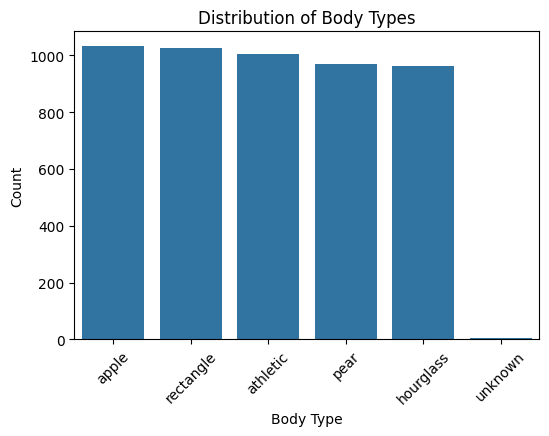

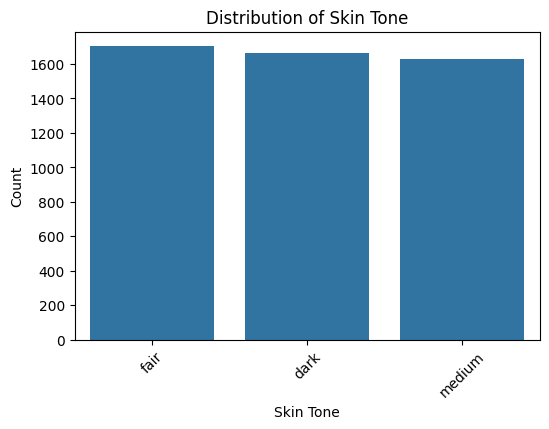

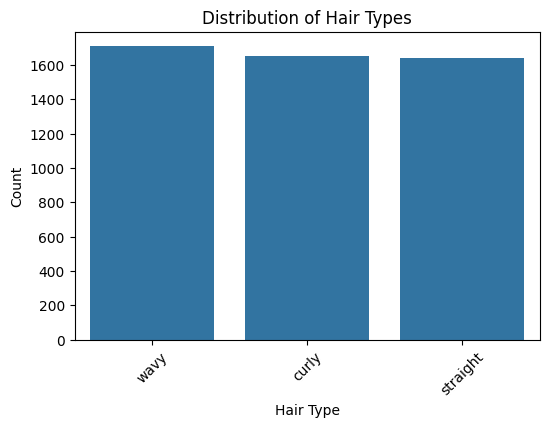

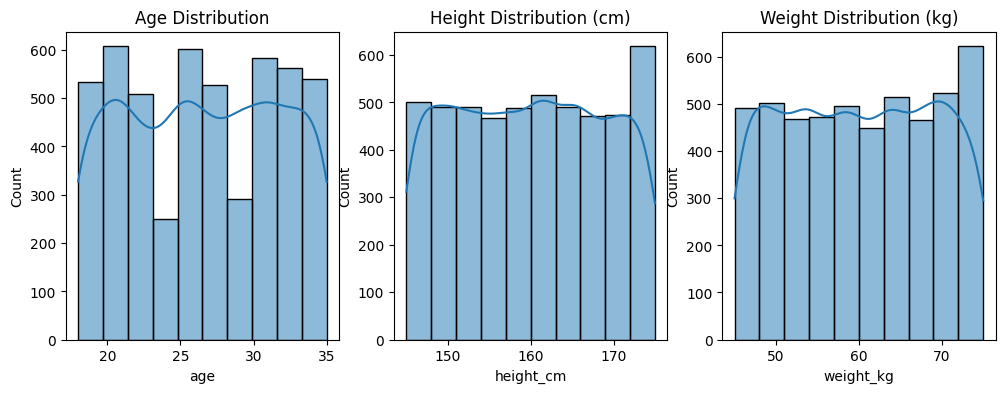

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Body type distribution
plt.figure(figsize=(6,4))
sns.countplot(data=users, x='body_type', order=users['body_type'].value_counts().index)
plt.title("Distribution of Body Types")
plt.xlabel("Body Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Skin tone distribution
plt.figure(figsize=(6,4))
sns.countplot(data=users, x='skin_tone', order=users['skin_tone'].value_counts().index)
plt.title("Distribution of Skin Tone")
plt.xlabel("Skin Tone")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Hair type distribution
plt.figure(figsize=(6,4))
sns.countplot(data=users, x='hair_type', order=users['hair_type'].value_counts().index)
plt.title("Distribution of Hair Types")
plt.xlabel("Hair Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Numeric distribution: Age, Height, Weight
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(users['age'], bins=10, kde=True)
plt.title("Age Distribution")

plt.subplot(1,3,2)
sns.histplot(users['height_cm'], bins=10, kde=True)
plt.title("Height Distribution (cm)")

plt.subplot(1,3,3)
sns.histplot(users['weight_kg'], bins=10, kde=True)
plt.title("Weight Distribution (kg)")
plt.show()

### OUTFIT DATASET VISUALS

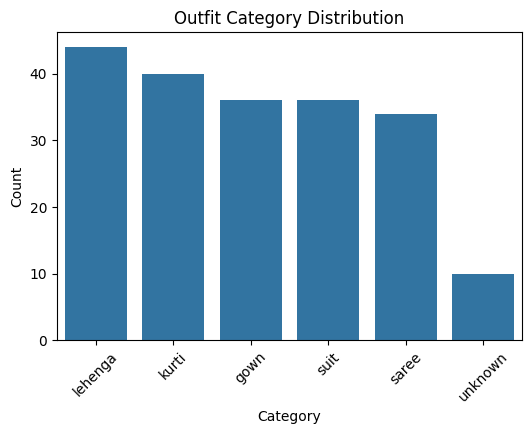

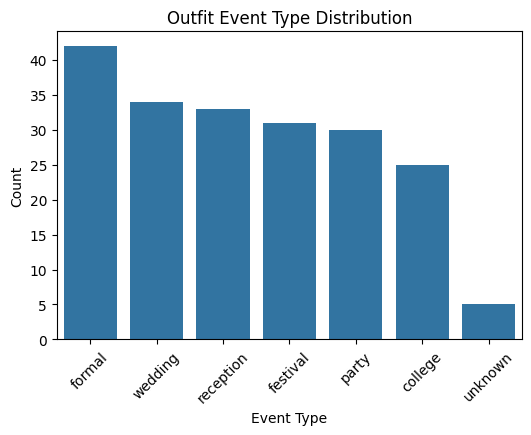

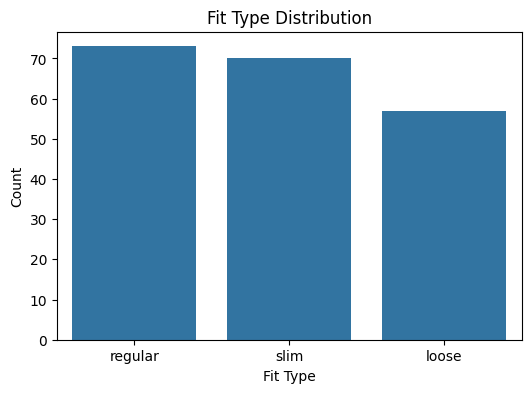

In [59]:
# Category distribution
plt.figure(figsize=(6,4))
sns.countplot(data=outfits, x='category', order=outfits['category'].value_counts().index)
plt.title("Outfit Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Event type distribution
plt.figure(figsize=(6,4))
sns.countplot(data=outfits, x='event_type', order=outfits['event_type'].value_counts().index)
plt.title("Outfit Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Fit type distribution
plt.figure(figsize=(6,4))
sns.countplot(data=outfits, x='fit_type', order=outfits['fit_type'].value_counts().index)
plt.title("Fit Type Distribution")
plt.xlabel("Fit Type")
plt.ylabel("Count")
plt.show()

## SKINCARE DATASET VISUALS


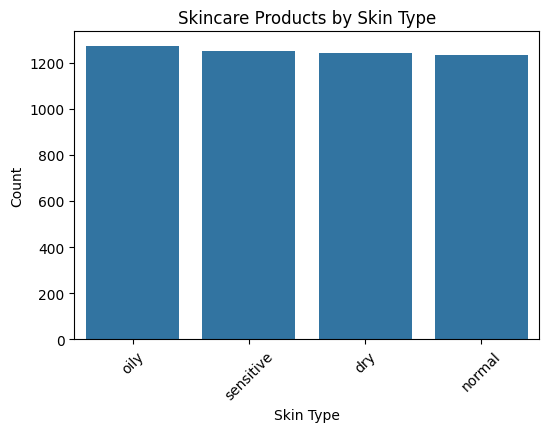

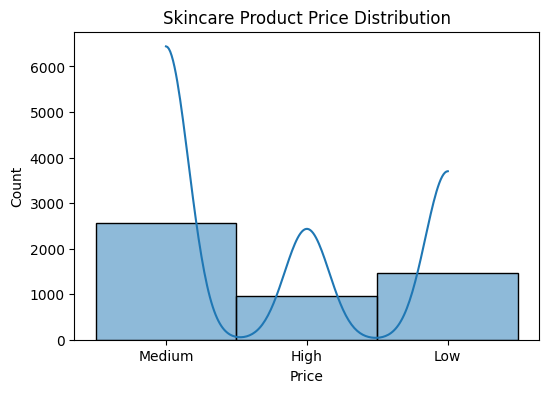

In [60]:
# Skin type distribution
plt.figure(figsize=(6,4))
sns.countplot(data=skincare, x='skin_type', order=skincare['skin_type'].value_counts().index)
plt.title("Skincare Products by Skin Type")
plt.xlabel("Skin Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# If price exists
if 'price_range' in skincare.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(skincare['price_range'], bins=20, kde=True)
    plt.title("Skincare Product Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Count")
    plt.show()

## HAIRCARE DATASET VISUALS

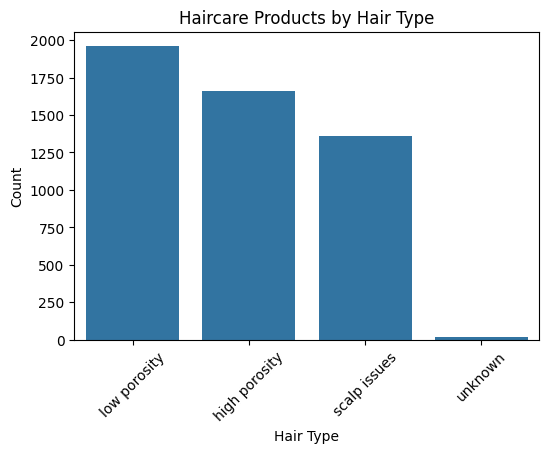

In [61]:
# Hair type distribution
plt.figure(figsize=(6,4))
sns.countplot(data=haircare, x='hair_type', order=haircare['hair_type'].value_counts().index)
plt.title("Haircare Products by Hair Type")
plt.xlabel("Hair Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()



## recommendation dataset visuals

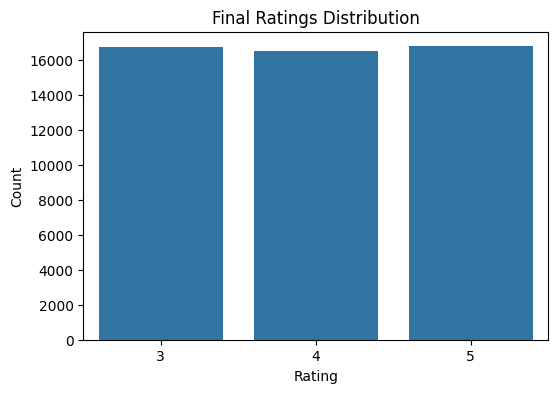

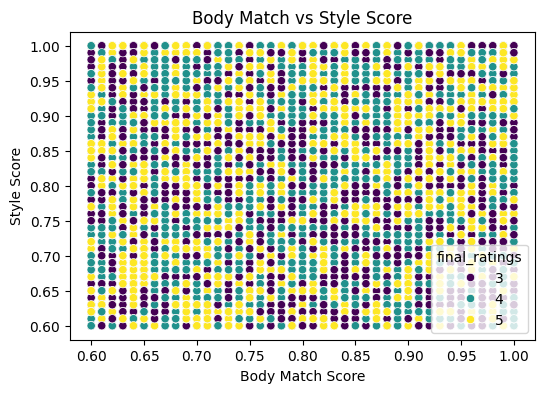

In [62]:
# Final ratings distribution
plt.figure(figsize=(6,4))
sns.countplot(data=recommendation, x='final_ratings', order=sorted(recommendation['final_ratings'].unique()))
plt.title("Final Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Body match score vs style score scatter
plt.figure(figsize=(6,4))
sns.scatterplot(data=recommendation, x='body_match_score', y='style_score', hue='final_ratings', palette='viridis')
plt.title("Body Match vs Style Score")
plt.xlabel("Body Match Score")
plt.ylabel("Style Score")
plt.show()

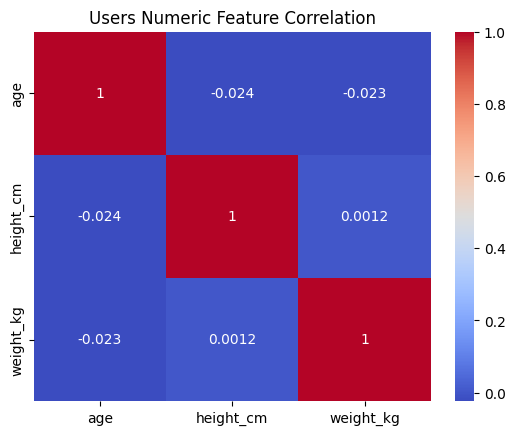

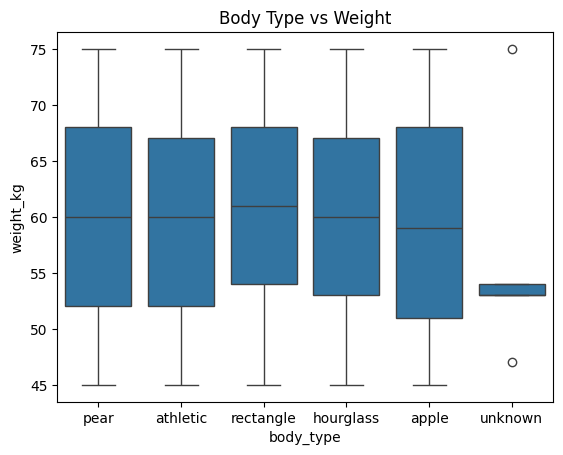

In [63]:
## USER DATASETS ===== Correlation between numeric features
import seaborn as sns
import matplotlib.pyplot as plt

corr = users[['age','height_cm','weight_kg']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Users Numeric Feature Correlation")
plt.show()

sns.boxplot(data=users, x='body_type', y='weight_kg')
plt.title("Body Type vs Weight")
plt.show()

In [64]:
pd.crosstab(outfits['category'], outfits['event_type'])

event_type,college,festival,formal,party,reception,unknown,wedding
category,,,,,,,
gown,4,4,11,4,5,1,7
kurti,6,4,10,7,4,1,8
lehenga,2,10,8,12,6,1,5
saree,2,5,4,4,9,0,10
suit,7,8,6,3,7,2,3
unknown,4,0,3,0,2,0,1


In [65]:
pd.crosstab(skincare['skin_type'], skincare['product_category'])

product_category,Cleanser,Moisturizer,Serum,Sunscreen,Toner
skin_type,,,,,
dry,267,249,249,259,218
normal,253,265,223,260,233
oily,240,249,263,252,268
sensitive,274,249,233,250,246


In [66]:
pd.crosstab(skincare['skin_type'], skincare['product_category'])

product_category,Cleanser,Moisturizer,Serum,Sunscreen,Toner
skin_type,,,,,
dry,267,249,249,259,218
normal,253,265,223,260,233
oily,240,249,263,252,268
sensitive,274,249,233,250,246


## Distribution  check

In [69]:
## USERS DATASETS
print("Users - Body Type Distribution (%)")
print(users['body_type'].value_counts(normalize=True) * 100)
print("\nUsers - Gender Distribution (%)")
print(users['gender'].value_counts(normalize=True) * 100)
print("\nUsers - Skin Tone Distribution (%)")
print(users['skin_tone'].value_counts(normalize=True) * 100)
print("\nUsers - Hair Type Distribution (%)")
print(users['hair_type'].value_counts(normalize=True) * 100)


Users - Body Type Distribution (%)
body_type
apple        20.66
rectangle    20.50
athletic     20.10
pear         19.36
hourglass    19.28
unknown       0.10
Name: proportion, dtype: float64

Users - Gender Distribution (%)
gender
female    100.0
Name: proportion, dtype: float64

Users - Skin Tone Distribution (%)
skin_tone
fair      34.06
dark      33.32
medium    32.62
Name: proportion, dtype: float64

Users - Hair Type Distribution (%)
hair_type
wavy        34.16
curly       33.02
straight    32.82
Name: proportion, dtype: float64


In [70]:
## outfit datasets
print("\nOutfits - Category Distribution (%)")
print(outfits['category'].value_counts(normalize=True) * 100)
print("\nOutfits - Event Type Distribution (%)")
print(outfits['event_type'].value_counts(normalize=True) * 100)
print("\nOutfits - Fit Type Distribution (%)")
print(outfits['fit_type'].value_counts(normalize=True) * 100)



Outfits - Category Distribution (%)
category
lehenga    22.0
kurti      20.0
gown       18.0
suit       18.0
saree      17.0
unknown     5.0
Name: proportion, dtype: float64

Outfits - Event Type Distribution (%)
event_type
formal       21.0
wedding      17.0
reception    16.5
festival     15.5
party        15.0
college      12.5
unknown       2.5
Name: proportion, dtype: float64

Outfits - Fit Type Distribution (%)
fit_type
regular    36.5
slim       35.0
loose      28.5
Name: proportion, dtype: float64


In [71]:
print("\nSkincare - Skin Type Distribution (%)")
print(skincare['skin_type'].value_counts(normalize=True) * 100)
print("\nSkincare - Product Category Distribution (%)")
print(skincare['product_category'].value_counts(normalize=True) * 100)



Skincare - Skin Type Distribution (%)
skin_type
oily         25.44
sensitive    25.04
dry          24.84
normal       24.68
Name: proportion, dtype: float64

Skincare - Product Category Distribution (%)
product_category
Cleanser       20.68
Sunscreen      20.42
Moisturizer    20.24
Serum          19.36
Toner          19.30
Name: proportion, dtype: float64


In [72]:
print("\nHaircare - Hair Type Distribution (%)")
print(haircare['hair_type'].value_counts(normalize=True) * 100)
print("\nHaircare - Routine Type Distribution (%)")
print(haircare['routine_type'].value_counts(normalize=True) * 100)



Haircare - Hair Type Distribution (%)
hair_type
low porosity     39.18
high porosity    33.20
scalp issues     27.22
unknown           0.40
Name: proportion, dtype: float64

Haircare - Routine Type Distribution (%)
routine_type
Wash         53.0
Treatment    47.0
Name: proportion, dtype: float64


In [73]:
print("\nRecommendation - Final Ratings Distribution (%)")
print(recommendation['final_ratings'].value_counts(normalize=True) * 100)
print("\nRecommendation - Event Type Distribution (%)")
print(recommendation['event_type'].value_counts(normalize=True) * 100)


Recommendation - Final Ratings Distribution (%)
final_ratings
5    33.528
3    33.504
4    32.968
Name: proportion, dtype: float64

Recommendation - Event Type Distribution (%)
event_type
formal       21.170
reception    17.458
wedding      16.762
festival     16.554
party        15.112
college      12.944
Name: proportion, dtype: float64


In [74]:
# USERS ==== Numeric: age, height_cm, weight_kg
for col in ['age', 'height_cm', 'weight_kg']:
    Q1 = users[col].quantile(0.25)
    Q3 = users[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    users[col] = np.clip(users[col], lower, upper)
print("Users outliers handled.")


Users outliers handled.


In [75]:
# Skincare dataset
# No numeric columns, so nothing to do
print("skincare dataset has no numeric columns to handle.")


#  Haircare dataset
# No numeric columns, so nothing to do
print("Haircare dataset has no numeric columns to handle.")

#  Outfits dataset
# No numeric columns, so nothing to do
print("Outfits dataset has no numeric columns to handle.")

skincare dataset has no numeric columns to handle.
Haircare dataset has no numeric columns to handle.
Outfits dataset has no numeric columns to handle.


In [76]:
# Numeric: body_match_score, style_score, final_ratings
for col in ['body_match_score','style_score','final_ratings']:
    Q1 = recommendation[col].quantile(0.25)
    Q3 = recommendation[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    recommendation[col] = np.clip(recommendation[col], lower, upper)
print("Recommendation outliers handled.")

Recommendation outliers handled.


In [77]:
print(users.shape)
print(outfits.shape)
print(skincare.shape)
print(haircare.shape)
print(recommendation.shape)

(5000, 9)
(200, 6)
(5000, 5)
(5000, 4)
(50000, 6)


In [78]:
# Save the cleaned datasets to CSV
outfits.to_csv("datasets/outfits_cleaned.csv", index=False)
users.to_csv("datasets/users_cleaned.csv", index=False)
skincare.to_csv("datasets/skincare_cleaned.csv", index=False)
haircare.to_csv("datasets/haircare_cleaned.csv", index=False)
recommendation.to_csv("datasets/recommendation_cleaned.csv", index=False)

print("All cleaned datasets have been saved successfully.")

All cleaned datasets have been saved successfully.
